Saving test.jpeg to test (3).jpeg


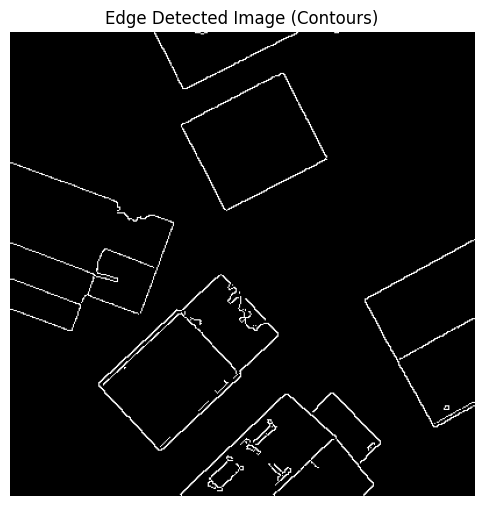

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# Upload the file
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

# Load the image
image = cv2.imread(image_path)
if image is None:
    raise ValueError("Image not found or invalid file format.")

# Preprocess: Edge Detection using Canny
def detect_edges(image):
    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blurred_image = cv2.GaussianBlur(gray_image, (5, 5), 0)
    edges = cv2.Canny(blurred_image, 50, 150)
    return edges

# Process: Detect edges and contours
edges = detect_edges(image)
contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Visualize the results
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(edges, cmap='gray')
plt.title('Edge Detected Image (Contours)')
plt.axis('off')


plt.tight_layout()
plt.show()


Saving test2.jpeg to test2 (1).jpeg


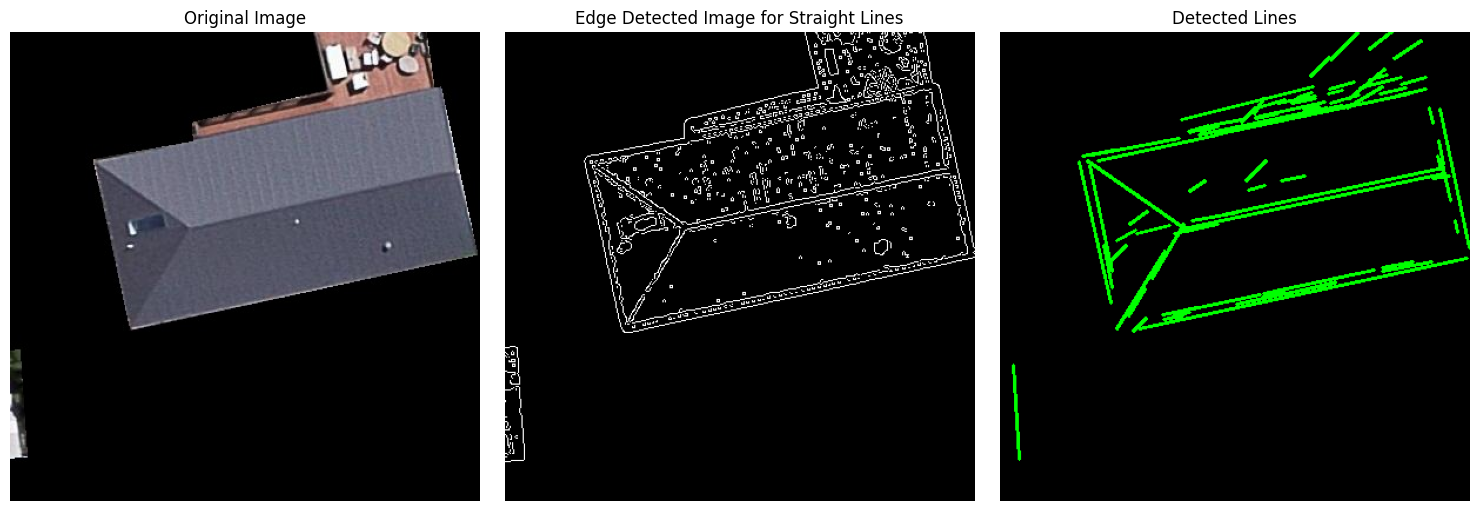

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# File upload
uploaded = files.upload()
image_path = list(uploaded.keys())[0]  # Get the uploaded file's name

# Preprocessing with Sobel filters to emphasize straight edges
def preprocess_image_for_straight_lines(image):
    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blurred_image = cv2.GaussianBlur(gray_image, (5, 5), 0)

    # Sobel filters to detect horizontal and vertical edges
    sobel_x = cv2.Sobel(blurred_image, cv2.CV_64F, 1, 0, ksize=3)  # Horizontal edges
    sobel_y = cv2.Sobel(blurred_image, cv2.CV_64F, 0, 1, ksize=3)  # Vertical edges

    # Calculate the gradient magnitude
    gradient_magnitude = np.sqrt(sobel_x**2 + sobel_y**2)
    gradient_magnitude = np.uint8(255 * gradient_magnitude / np.max(gradient_magnitude))

    # Threshold to keep strong edges (potentially straight lines)
    _, thresholded = cv2.threshold(gradient_magnitude, 10, 255, cv2.THRESH_BINARY)
    return thresholded

# Canny edge detection after preprocessing for straight lines
def enhanced_canny_edge_detector(image, low_threshold=50, high_threshold=150):
    preprocessed_image = preprocess_image_for_straight_lines(image)
    edges = cv2.Canny(preprocessed_image, low_threshold, high_threshold)
    return edges

# Hough Line detection (unchanged, provided for completeness)
def hough_line_detection(edge_image, threshold=50, min_line_length=10, max_line_gap=5):
    lines = cv2.HoughLinesP(edge_image, 1, np.pi / 180, threshold, minLineLength=min_line_length, maxLineGap=max_line_gap)
    line_img = np.zeros((edge_image.shape[0], edge_image.shape[1], 3), dtype=np.uint8)
    if lines is not None:
        for line in lines:
            for x1, y1, x2, y2 in line:
                cv2.line(line_img, (x1, y1), (x2, y2), (0, 255, 0), 2)
    return line_img, lines

# Read image
image = cv2.imread(image_path)

# Process image
edges = enhanced_canny_edge_detector(image)
line_image, lines = hough_line_detection(edges)

# Plotting results
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(edges, cmap='gray')
plt.title('Edge Detected Image for Straight Lines')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(line_image)
plt.title('Detected Lines')
plt.axis('off')

plt.tight_layout()
plt.show()
